<a href="https://colab.research.google.com/github/dheerajnalla09/AIML/blob/main/RFM_clustering_online_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RFM Customer Clustering (Online Retail)
Use case: **Identify high-value customers to target** using RFM (Recency, Frequency, Monetary) features and clustering.

This notebook includes detailed explanations and code cells for preprocessing, EDA, feature engineering, K-Means and Hierarchical clustering, and business recommendations.

## 1) Import libraries
We import common libraries used for data analysis and clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline
sns.set(style='whitegrid')
print('Libraries imported')

Libraries imported


## 2) Load dataset
The notebook will try to read 'online_retail.csv' from the working directory. If not found, a small sample dataset (from the user) is loaded as fallback.

In [ ]:
import os
csv_path = r"C:\Users\admin\Documents\DS Class\ML\Unsupervised\K-means\OnlineRetail.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path, encoding='ISO-8859-1')
    print('Loaded dataset from', csv_path)
else:
    data = [
        [536365,'85123A','WHITE HANGING HEART T-LIGHT HOLDER',6,'01-12-2010 08:26',2.55,17850,'United Kingdom'],
        [536365,'71053','WHITE METAL LANTERN',6,'01-12-2010 08:26',3.39,17850,'United Kingdom'],
        [536365,'84406B','CREAM CUPID HEARTS COAT HANGER',8,'01-12-2010 08:26',2.75,17850,'United Kingdom'],
        [536365,'84029G','KNITTED UNION FLAG HOT WATER BOTTLE',6,'01-12-2010 08:26',3.39,17850,'United Kingdom'],
        [536365,'84029E','RED WOOLLY HOTTIE WHITE HEART',6,'01-12-2010 08:26',3.39,17850,'United Kingdom'],
        [536365,'22752','SET 7 BABUSHKA NESTING BOXES',2,'01-12-2010 08:26',7.65,17850,'United Kingdom'],
        [536365,'21730','GLASS STAR FROSTED T-LIGHT HOLDER',6,'01-12-2010 08:26',4.25,17850,'United Kingdom'],
        [536366,'22633','HAND WARMER UNION JACK',6,'01-12-2010 08:28',1.85,17850,'United Kingdom'],
        [536366,'22632','HAND WARMER RED POLKA DOT',6,'01-12-2010 08:28',1.85,17850,'United Kingdom'],
        [536367,'84879','ASSORTED COLOUR BIRD ORNAMENT',32,'01-12-2010 08:34',1.69,13047,'United Kingdom'],
        [536367,'22745','POPPY\'S PLAYHOUSE BEDROOM',6,'01-12-2010 08:34',2.10,13047,'United Kingdom'],
        [536367,'22748','POPPY\'S PLAYHOUSE KITCHEN',6,'01-12-2010 08:34',2.10,13047,'United Kingdom']
    ]
    cols = ['InvoiceNo','StockCode','Description','Quantity','InvoiceDate','UnitPrice','CustomerID','Country']
    df = pd.DataFrame(data, columns=cols)
    print('Loaded fallback sample dataset')

df.head()

Loaded dataset from C:\Users\admin\Documents\DS Class\ML\Unsupervised\K-means\OnlineRetail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Parse dates and ensure numeric types
Convert InvoiceDate to datetime and Quantity/UnitPrice to numeric.

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## 3) Data cleaning
Remove rows without CustomerID, negative quantities (returns), and create TotalPrice.

In [ ]:
# Drop missing CustomerID
df = df.dropna(subset=['CustomerID'])
# Remove cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
# Keep only positive quantity and unit price
df = df[(df['Quantity']>0) & (df['UnitPrice']>0)]
# Total price per row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 4) RFM feature engineering
Compute Recency, Frequency, Monetary per CustomerID. Recency = days since last purchase relative to snapshot date.

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
rfm.columns = ['CustomerID','Recency','Frequency','Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### Transform and scale RFM
Log-transform Frequency and Monetary to reduce skew, then standardize features for distance-based clustering.

In [ ]:
rfm['Frequency'] = rfm['Frequency'].replace(0, 0.0001)
rfm['Monetary'] = rfm['Monetary'].replace(0, 0.0001)
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
features = rfm[['Recency','Frequency_log','Monetary_log']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled[:5]

array([[ 2.33457414, -0.95521426,  3.70622476],
       [-0.90534032,  1.07442519,  1.41184341],
       [-0.17535959,  0.38630445,  0.7164889 ],
       [-0.73534481, -0.95521426,  0.6987394 ],
       [ 2.17457836, -0.95521426, -0.6189622 ]])

## 5) EDA
Visualize distributions and relationships of RFM features.

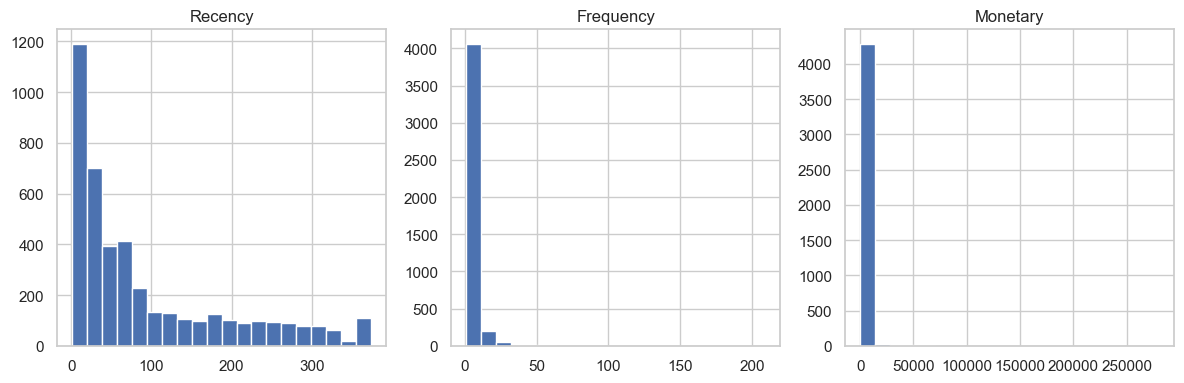

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(rfm['Recency'], bins=20)
plt.title('Recency')
plt.subplot(1,3,2)
plt.hist(rfm['Frequency'], bins=20)
plt.title('Frequency')
plt.subplot(1,3,3)
plt.hist(rfm['Monetary'], bins=20)
plt.title('Monetary')
plt.tight_layout()
plt.show()

### PCA for visualization
Project scaled features to 2D for plotting clusters.

Explained variance ratio: [0.72090693 0.21557873]


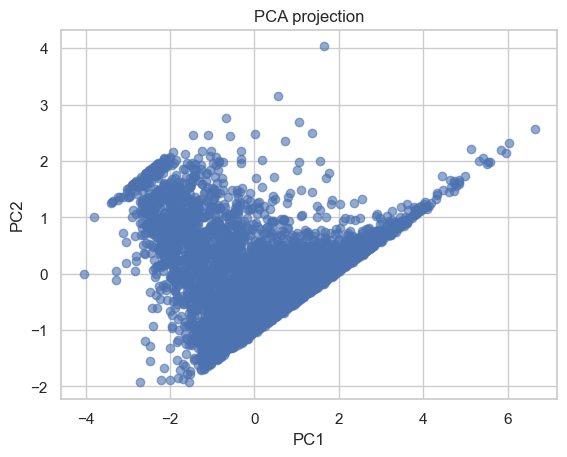

In [ ]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(features_scaled)
print('Explained variance ratio:', pca.explained_variance_ratio_)
import matplotlib.pyplot as plt
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection')
plt.show()

## 6) K-Means clustering
Use elbow (inertia) and silhouette to choose k.

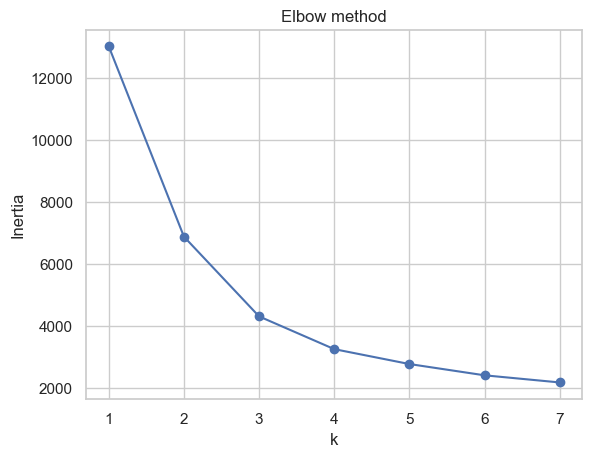

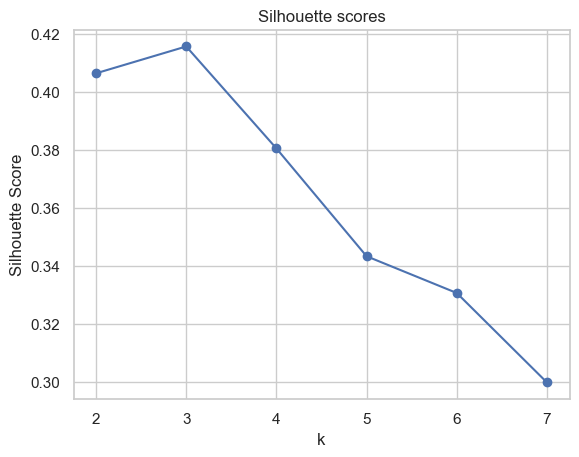

In [ ]:
inertia = []
k_range = range(1,8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)
plt.plot(k_range, inertia, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

sil_scores = []
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    sil_scores.append(silhouette_score(features_scaled, labels))
plt.plot(range(2,8), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette scores')
plt.show()

In [ ]:
### Fit KMeans and attach cluster labels
Choose k based on plots (example uses k=3).

In [ ]:
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=20)
rfm['KMeans_Cluster'] = km.fit_predict(features_scaled)
centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['Recency','Frequency_log','Monetary_log'])
centers_df['Frequency'] = np.expm1(centers_df['Frequency_log'])
centers_df['Monetary'] = np.expm1(centers_df['Monetary_log'])
centers_df

,Recency,Frequency_log,Monetary_log,Frequency,Monetary
0,54.972031,1.058233,6.147026,1.881275,466.325342
1,30.100529,2.166693,7.999945,7.729368,2979.795130
2,255.442170,0.833083,5.620868,1.300401,275.129086


### Visualize KMeans clusters on PCA 2D space

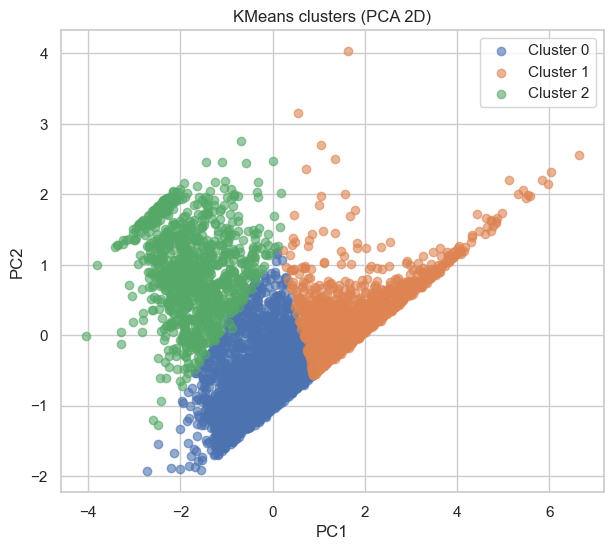

In [ ]:
plt.figure(figsize=(7,6))
for i in range(k):
    idx = rfm['KMeans_Cluster']==i
    plt.scatter(rfm_pca[idx,0], rfm_pca[idx,1], label=f'Cluster {i}', alpha=0.6)
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters (PCA 2D)')
plt.show()

## 7) Cluster profiling
Compute average RFM per cluster and count.

In [ ]:
profile = rfm.groupby('KMeans_Cluster').agg({'Recency':'mean','Frequency':'mean','Monetary':'mean','CustomerID':'count'
}).rename(columns={'CustomerID':'Count'}).reset_index()
profile

,KMeans_Cluster,Recency,Frequency,Monetary,Count
0,0,54.857073,2.046169,615.235984,2036
1,1,30.100529,9.829932,5494.341156,1323
2,2,255.271706,1.390194,398.134924,979


## 8) Hierarchical clustering
Compute linkage and dendrogram, then AgglomerativeClustering.

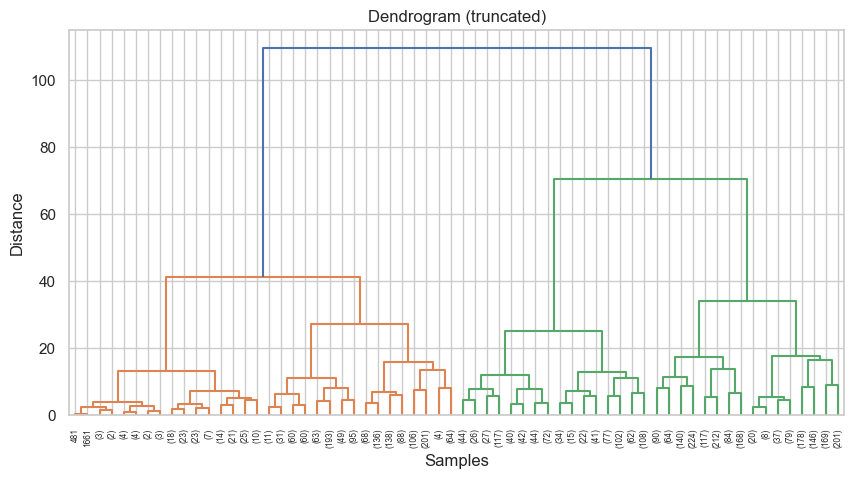

,CustomerID,Hierarchical_Cluster
0,12346.0,0
1,12347.0,0
2,12348.0,0
3,12349.0,1
4,12350.0,2
5,12352.0,0
6,12353.0,2
7,12354.0,2
8,12355.0,2
9,12356.0,0


In [ ]:
linked = linkage(features_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram (truncated)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
rfm['Hierarchical_Cluster'] = agg.fit_predict(features_scaled)
rfm[['CustomerID','Hierarchical_Cluster']].head(10)

## 9) Compare and business recommendation
Identify best clusters for targeting (high Monetary & Frequency, low Recency).

In [ ]:
profile = rfm.groupby('KMeans_Cluster').agg({'Recency':'mean','Frequency':'mean','Monetary':'mean','CustomerID':'count'}).rename(columns={'CustomerID':'Count'}).reset_index()
best = profile[(profile['Monetary']>profile['Monetary'].mean()) & (profile['Frequency']>profile['Frequency'].mean()) & (profile['Recency']<profile['Recency'].mean())]
print('Cluster profiles:')
profile

print('\nRecommended clusters to target:')
best

Cluster profiles:

Recommended clusters to target:


,KMeans_Cluster,Recency,Frequency,Monetary,Count
1,1,30.100529,9.829932,5494.341156,1323
